# LeetCode #119: Pascal's Triangle II

https://leetcode.com/problems/pascals-triangle-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(k^2)$ | $O(k^2)$ |
| **Rolling Array** ★ | $O(k^2)$ | $O(k)$ |

---

## Understanding the Methods

### Brute Force
Generate all rows up to rowIndex exactly as in problem 118, then return only the last row. Wastes $O(k^2)$ space storing intermediate rows that are never needed in the output.

### Optimal: Rolling Array ★
Maintain a single array of size k+1, initialized to [1, 0, …, 0]. For each new row, iterate from right to left: `row[j] += row[j-1]`. Traversing right-to-left ensures each element reads the previous row's value at `j-1` before it is overwritten.

**Why this is better than Brute Force:** Only one array of size k+1 is ever allocated — $O(k)$ space instead of $O(k^2)$. Time is identical; the constant factor is also lower since no list-of-lists is built.

**Constraints:**
* 0 ≤ rowIndex ≤ 33

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<int> GetRow(int rowIndex) {
        var row = new int[rowIndex + 1];
        row[0] = 1;
        // Update right-to-left so each position reads the previous row's left neighbor
        for (int i = 1; i <= rowIndex; i++)
            for (int j = i; j >= 1; j--)
                row[j] += row[j - 1];
        return row;
    }
}

### Python

In [ ]:
class Solution:
    def getRow(self, rowIndex: int) -> List[int]:
        row = [0] * (rowIndex + 1)
        row[0] = 1
        # Update right-to-left so each position reads the previous row's left neighbor
        for i in range(1, rowIndex + 1):
            for j in range(i, 0, -1):
                row[j] += row[j - 1]
        return row

### Go

In [ ]:
func getRow(rowIndex int) []int {
    row := make([]int, rowIndex+1)
    row[0] = 1
    // Update right-to-left so each position reads the previous row's left neighbor
    for i := 1; i <= rowIndex; i++ {
        for j := i; j >= 1; j-- {
            row[j] += row[j-1]
        }
    }
    return row
}

### Rust

In [ ]:
pub fn get_row(row_index: i32) -> Vec<i32> {
    let n = row_index as usize;
    let mut row = vec![0i32; n + 1];
    row[0] = 1;
    // Update right-to-left so each position reads the previous row's left neighbor
    for i in 1..=n {
        for j in (1..=i).rev() {
            row[j] += row[j - 1];
        }
    }
    row
}

## Example Scenarios

**1. Common Case**
**Input:** rowIndex = 3
Start: [1, 0, 0, 0]. i=1: j=1 → row[1]+=row[0] → [1,1,0,0]. i=2: j=2→ row[2]+=row[1]=1 → [1,1,1,0], j=1 → row[1]+=row[0]=1 → [1,2,1,0]. i=3: j=3→1, j=2→2+1=3, j=1→1+1=2 → wait, i=3: row[3]+=row[2]=1→1, row[2]+=row[1]=2→3, row[1]+=row[0]=1→3. Final: **[1, 3, 3, 1]**.

**2. Slightly Complex — rowIndex = 4, tracing the right-to-left update**
**Input:** rowIndex = 4
After row i=3: [1,3,3,1,0]. i=4 pass (right-to-left): j=4: row[4]+=row[3]=1→1. j=3: row[3]+=row[2]=3→4. j=2: row[2]+=row[1]=3→6. j=1: row[1]+=row[0]=1→4. Final: **[1,4,6,4,1]**. Left-to-right order would corrupt row[1] before row[2] reads it — that's why descending order is essential.

**3. Edge Case: Time Factor — rowIndex = 33 (maximum)**
**Input:** rowIndex = 33
Total inner loop iterations: $\sum_{i=1}^{33} i = \frac{33 \cdot 34}{2} = 561$. Brute Force also does 561 additions but allocates 33 separate lists totaling $\frac{33 \cdot 34}{2} = 561$ integers. Rolling Array completes in 561 in-place additions with no allocation beyond the single size-34 array. The largest value is C(33,16) = 1,166,803,110 — fits in a 32-bit signed integer ($< 2^{31} - 1$).

**4. Edge Case: Space Factor — single array vs full triangle**
**Input:** rowIndex = 33
Brute Force allocates a triangle of $1+2+\cdots+34 = 595$ integers plus the list-of-lists overhead. Rolling Array allocates exactly 34 integers regardless of rowIndex. For the maximum constraint the space ratio is $595:34 \approx 17.5\times$ — meaningful at scale, and the Rolling Array result can also be streamed from a fixed-size buffer.

**5. Almost-Impossible but Plausible — rowIndex = 0**
**Input:** rowIndex = 0
Array initialized to [1] (size 1). Outer loop range $i \in [1, 0]$ is empty — zero iterations. Returns **[1]** immediately. The right-to-left inner loop's range $j \in [i, 1]$ would also be empty for i=0, so no off-by-one risk regardless of loop order.

## Infographic

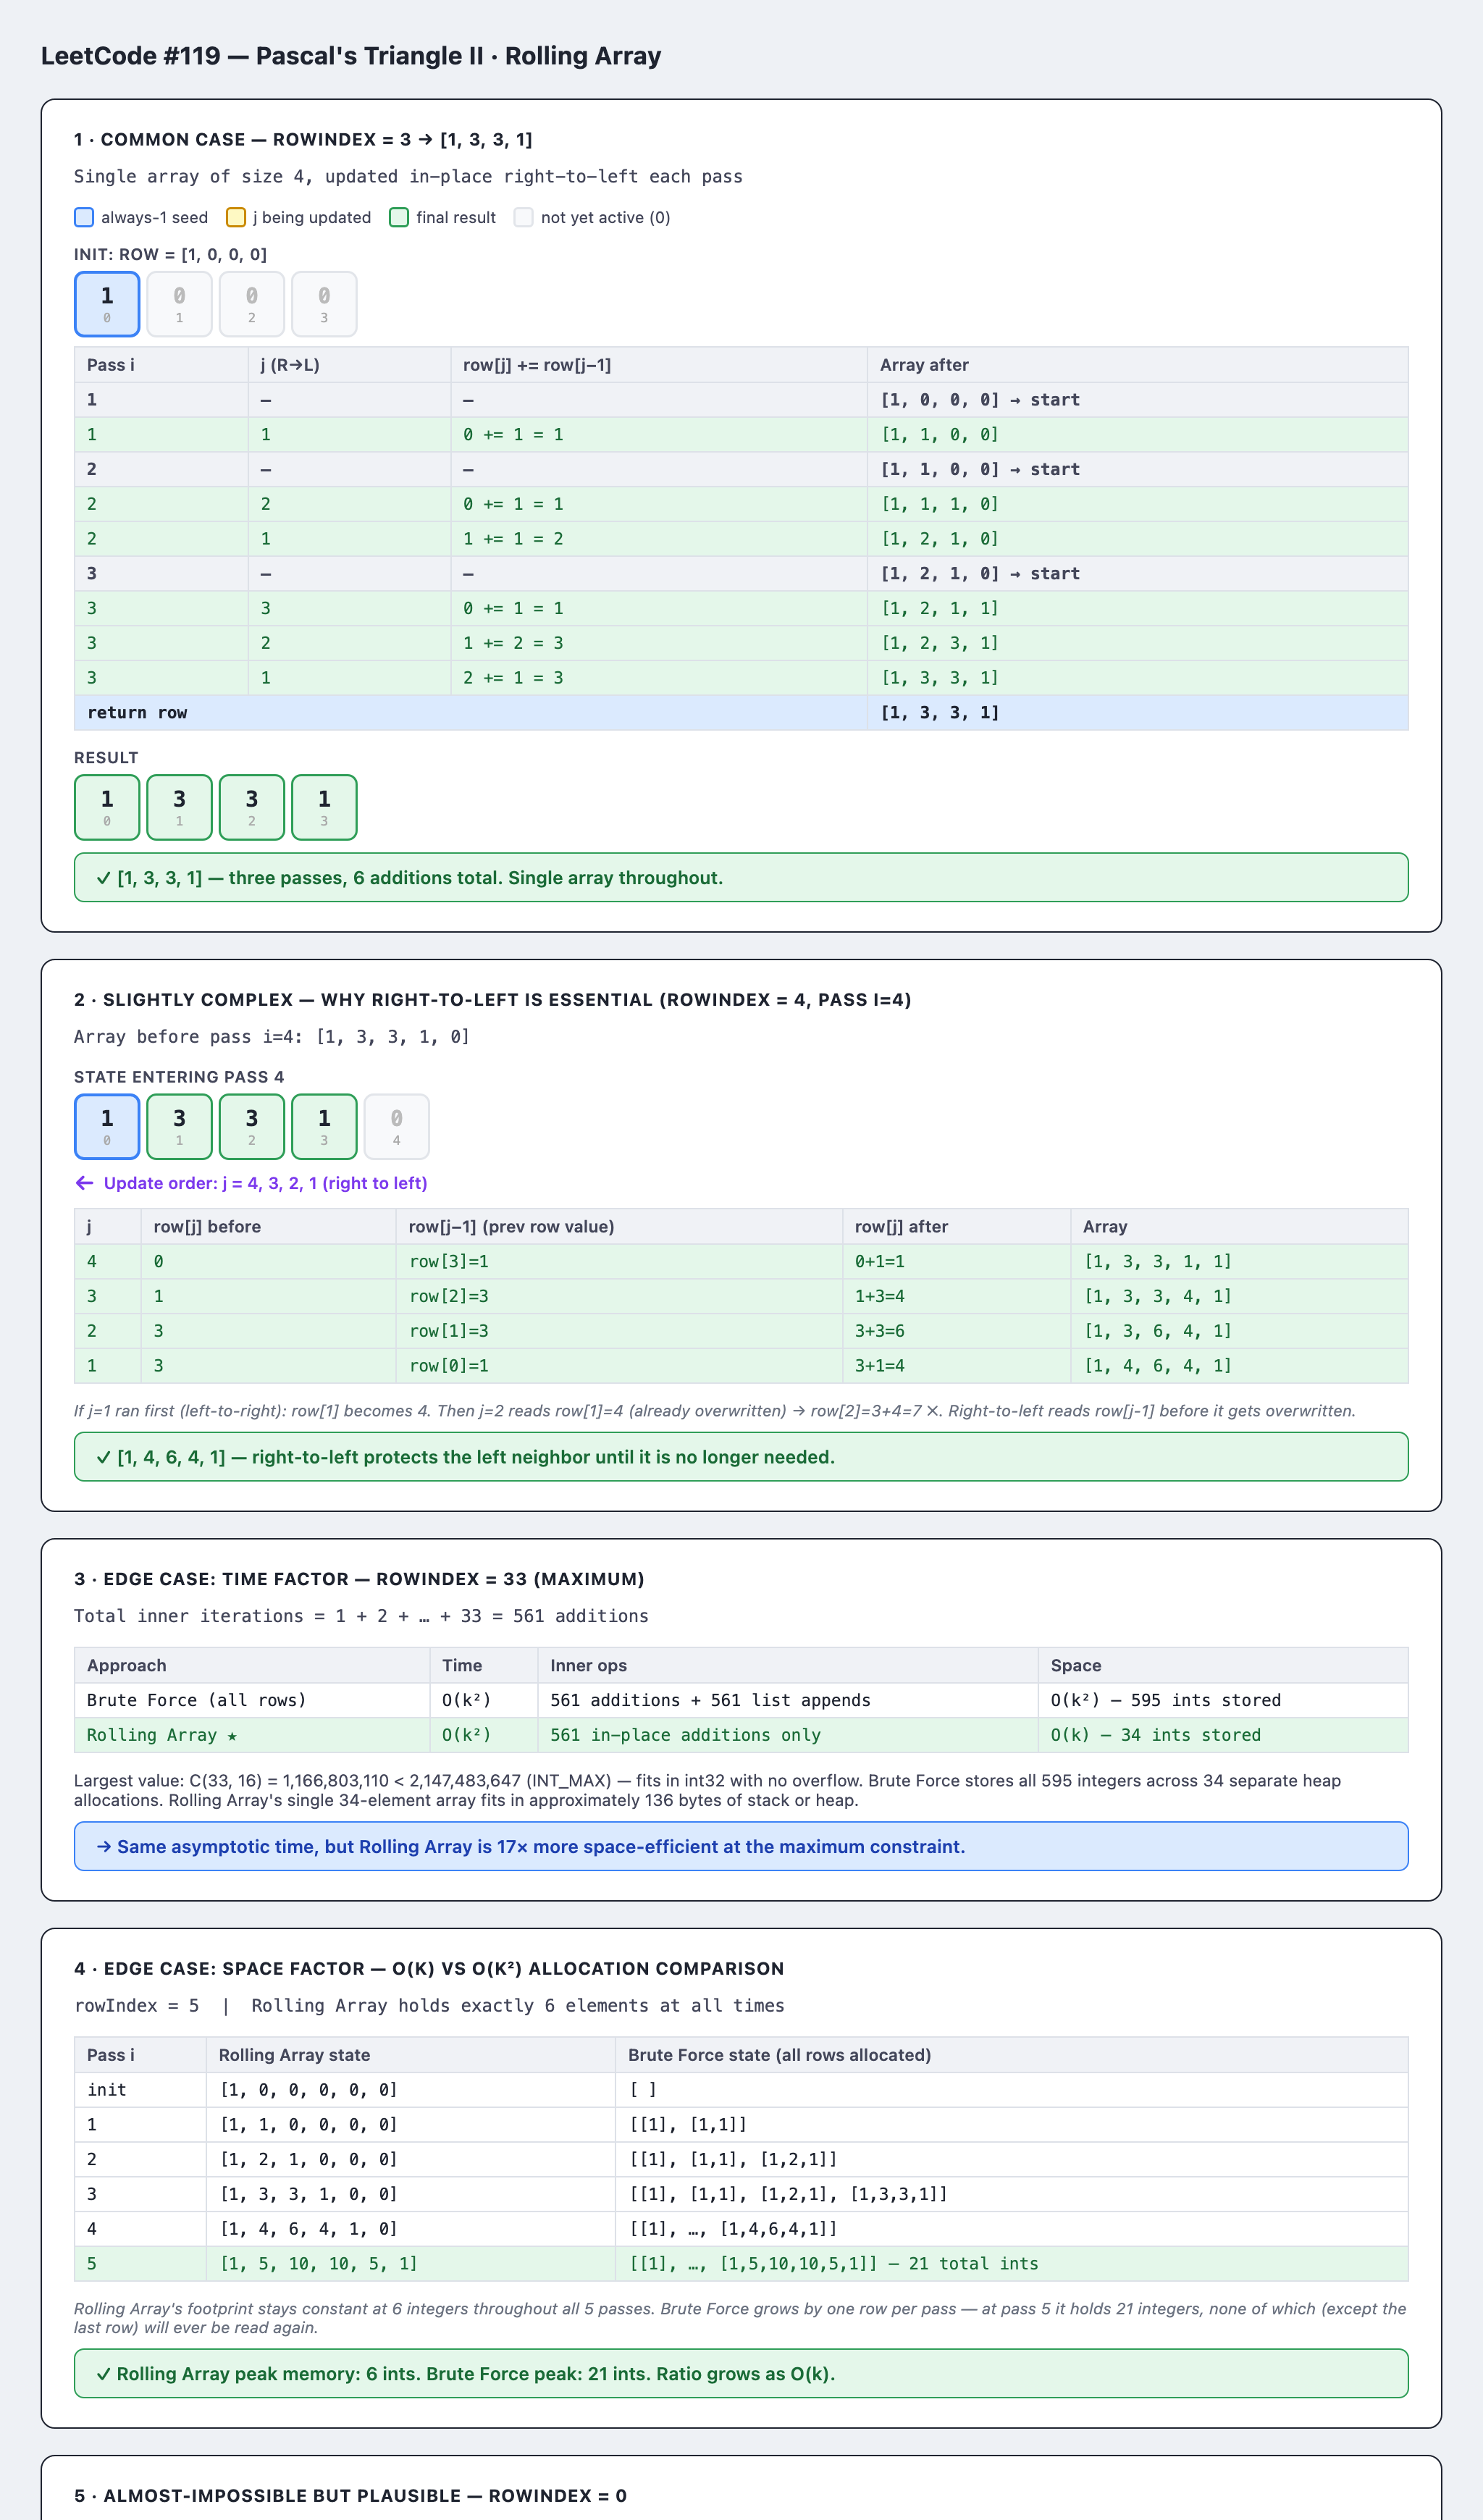